# NASA C-MAPSS RUL Prediction

## Data Preparation

This notebook prepares the raw NASA C-MAPSS dataset for machine learning.

The datasets used are:
- FD001
- FD002
- FD003
- FD004

In [14]:
import pandas as pd
import numpy as np
import os

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [15]:
DATA_PATH = "../data"

print(DATA_PATH)

../data


In [16]:
os.listdir(DATA_PATH)

['RUL_FD001.txt',
 'RUL_FD002.txt',
 'RUL_FD003.txt',
 'RUL_FD004.txt',
 'test_FD001.txt',
 'test_FD002.txt',
 'test_FD003.txt',
 'test_FD004.txt',
 'train_FD001.txt',
 'train_FD002.txt',
 'train_FD003.txt',
 'train_FD004.txt']

In [17]:
train_file = os.path.join(DATA_PATH, "train_FD001.txt")

print(train_file)

../data\train_FD001.txt


In [18]:
train_raw = pd.read_csv(
    train_file,
    sep=r"\s+",
    header=None
)

train_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [19]:
train_raw.shape

(20631, 26)

In [20]:
train_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [21]:
columns = [
    "unit",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

columns += [f"sensor_{i}" for i in range(1, 22)]

print(columns)

['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [22]:
train_raw.columns = columns

In [23]:
train_raw.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [24]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit          20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [25]:
train_raw.isnull().sum()

unit            0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
dtype: int64

In [26]:
train_raw.describe()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [27]:
import pandas as pd
import numpy as np
import os

In [28]:
DATA_PATH = "../data"

In [29]:
train_file = os.path.join(DATA_PATH, "train_FD001.txt")

train_raw = pd.read_csv(
    train_file,
    sep=r"\s+",
    header=None
)

In [30]:
columns = [
    "unit",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

columns += [f"sensor_{i}" for i in range(1, 22)]

train_raw.columns = columns

In [31]:
train_raw.duplicated().sum()

np.int64(0)

In [32]:
train_raw["unit"].nunique()

100

In [33]:
train_raw["unit"].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [34]:
engine_lifetimes = train_raw.groupby("unit")["cycle"].max()

engine_lifetimes.head(10)

unit
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64

In [35]:
max_cycle = train_raw.groupby("unit")["cycle"].transform("max")

train_raw["RUL"] = max_cycle - train_raw["cycle"]

In [36]:
train_raw.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [37]:
train_raw[["unit", "cycle", "RUL"]].head(20)

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [38]:
train_raw["RUL"].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

In [39]:
os.makedirs("../processed_data", exist_ok=True)

In [40]:
train_raw.to_csv(
    "../processed_data/train_FD001_clean.csv",
    index=False
)

PermissionError: [Errno 13] Permission denied: '../processed_data/train_FD001_clean.csv'

In [ ]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

print(sensor_columns)

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [ ]:
import pandas as pd
import numpy as np
import os

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
DATA_PATH = "../data"

print(DATA_PATH)

../data


In [ ]:
train_file = os.path.join(DATA_PATH, "train_FD001.txt")

train_raw = pd.read_csv(
    train_file,
    sep=r"\s+",
    header=None
)

train_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
columns = [
    "unit",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

columns += [f"sensor_{i}" for i in range(1, 22)]

train_raw.columns = columns

train_raw.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

print(sensor_columns)

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [ ]:
sensor_summary = train_raw[sensor_columns].agg(
    ["nunique", "std", "min", "max"]
).T

sensor_summary

,nunique,std,min,max
sensor_1,1.0,0.000000e+00,518.6700,518.6700
sensor_2,310.0,5.000533e-01,641.2100,644.5300
sensor_3,3012.0,6.131150e+00,1571.0400,1616.9100
sensor_4,4051.0,9.000605e+00,1382.2500,1441.4900
sensor_5,1.0,5.329200e-15,14.6200,14.6200
sensor_6,2.0,1.388985e-03,21.6000,21.6100
sensor_7,513.0,8.850923e-01,549.8500,556.0600
sensor_8,53.0,7.098548e-02,2387.9000,2388.5600
sensor_9,6403.0,2.208288e+01,9021.7300,9244.5900
sensor_10,1.0,0.000000e+00,1.3000,1.3000


In [ ]:
constant_sensors = [
    sensor for sensor in sensor_columns
    if train_raw[sensor].nunique() <= 1
]

print("Constant sensors:")
print(constant_sensors)

Constant sensors:
['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [ ]:
engine_1 = train_raw[train_raw["unit"] == 1]

engine_1.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
engine_1["cycle"].max()

np.int64(192)

In [ ]:
engine_1["cycle"].max()

np.int64(192)

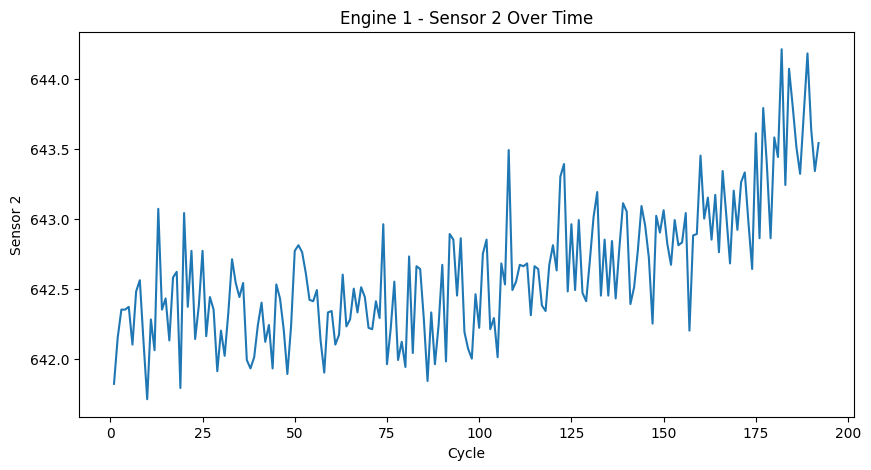

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_2"]
)

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Engine 1 - Sensor 2 Over Time")

plt.show()

## Progress Note — FD001 Data Preparation

So far, I have prepared and explored the NASA C-MAPSS FD001 training dataset.

### What I completed

- Loaded the FD001 training data from the raw `.txt` file.
- Converted the raw data into a Pandas DataFrame.
- Added meaningful column names:
  - Engine ID (`unit`)
  - Cycle
  - 3 operating settings
  - 21 sensor measurements
- Checked the structure and basic information of the dataset.
- Checked for missing values and duplicate rows.
- Examined the number of engines and their operating cycles.
- Created the Remaining Useful Life (RUL) value for the training data.
- Saved the cleaned FD001 training data as a CSV file.
- Created a list of the 21 sensor columns.
- Examined how much each sensor changes.
- Identified 6 constant sensors in FD001:
  - `sensor_1`
  - `sensor_5`
  - `sensor_10`
  - `sensor_16`
  - `sensor_18`
  - `sensor_19`
- Selected Engine 1 to examine its sensor measurements over its lifetime.
- Found that Engine 1 has 192 cycles.
- Plotted Sensor 2 against engine cycle to observe how the sensor changes over time.

### What I learned

Each row represents an engine at a particular cycle. The sensor values describe the engine's condition at that cycle. As the engine gets older, its sensor measurements can change, although the changes may not always be smooth.

The goal of the next steps is to determine which sensor measurements provide useful information for predicting Remaining Useful Life (RUL).

In [41]:
print("RUL" in train_raw.columns)

True


In [43]:
engine_1 = train_raw[train_raw["unit"] == 1]

engine_1[["cycle", "RUL"]].head(10)

,cycle,RUL
0,1,191
1,2,190
2,3,189
3,4,188
4,5,187
5,6,186
6,7,185
7,8,184
8,9,183
9,10,182


In [44]:
engine_1[["cycle", "RUL"]].tail(10)

,cycle,RUL
182,183,9
183,184,8
184,185,7
185,186,6
186,187,5
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


In [45]:
sensor_corr = train_raw[sensor_columns + ["RUL"]].corr()["RUL"].drop("RUL")

sensor_corr

sensor_1          NaN
sensor_2    -0.606484
sensor_3    -0.584520
sensor_4    -0.678948
sensor_5          NaN
sensor_6    -0.128348
sensor_7     0.657223
sensor_8    -0.563968
sensor_9    -0.390102
sensor_10         NaN
sensor_11   -0.696228
sensor_12    0.671983
sensor_13   -0.562569
sensor_14   -0.306769
sensor_15   -0.642667
sensor_16         NaN
sensor_17   -0.606154
sensor_18         NaN
sensor_19         NaN
sensor_20    0.629428
sensor_21    0.635662
Name: RUL, dtype: float64

In [46]:
sensor_corr = train_raw[sensor_columns + ["RUL"]].corr()["RUL"].drop("RUL")

sensor_corr

sensor_1          NaN
sensor_2    -0.606484
sensor_3    -0.584520
sensor_4    -0.678948
sensor_5          NaN
sensor_6    -0.128348
sensor_7     0.657223
sensor_8    -0.563968
sensor_9    -0.390102
sensor_10         NaN
sensor_11   -0.696228
sensor_12    0.671983
sensor_13   -0.562569
sensor_14   -0.306769
sensor_15   -0.642667
sensor_16         NaN
sensor_17   -0.606154
sensor_18         NaN
sensor_19         NaN
sensor_20    0.629428
sensor_21    0.635662
Name: RUL, dtype: float64

In [47]:
sensor_corr.abs().sort_values(ascending=False)

sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2     0.606484
sensor_17    0.606154
sensor_3     0.584520
sensor_8     0.563968
sensor_13    0.562569
sensor_9     0.390102
sensor_14    0.306769
sensor_6     0.128348
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

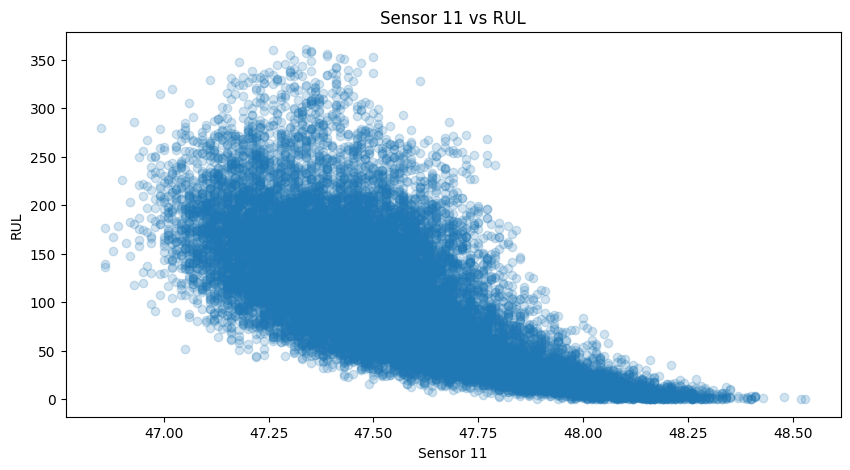

In [48]:
plt.figure(figsize=(10, 5))

plt.scatter(
    train_raw["sensor_11"],
    train_raw["RUL"],
    alpha=0.2
)

plt.xlabel("Sensor 11")
plt.ylabel("RUL")
plt.title("Sensor 11 vs RUL")

plt.show()

In [49]:
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

model_sensors = [
    sensor for sensor in sensor_columns
    if sensor not in constant_sensors
]

print("Number of sensors for modeling:", len(model_sensors))
print(model_sensors)

Number of sensors for modeling: 15
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [50]:
X = train_raw[model_sensors]
y = train_raw["RUL"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20631, 15)
y shape: (20631,)


In [51]:
test_file = os.path.join(DATA_PATH, "test_FD001.txt")

test_raw = pd.read_csv(
    test_file,
    sep=r"\s+",
    header=None
)

test_raw.columns = columns

test_raw.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [52]:
print("Number of test engines:", test_raw["unit"].nunique())
print("Number of test rows:", len(test_raw))

Number of test engines: 100
Number of test rows: 13096


In [53]:
rul_file = os.path.join(DATA_PATH, "RUL_FD001.txt")

test_rul = pd.read_csv(
    rul_file,
    sep=r"\s+",
    header=None
)

test_rul.columns = ["RUL"]

test_rul.head(10)

,RUL
0,112
1,98
2,69
3,82
4,91
5,93
6,91
7,95
8,111
9,96


In [54]:
print("Number of RUL values:", len(test_rul))
print("Number of test engines:", test_raw["unit"].nunique())

Number of RUL values: 100
Number of test engines: 100


In [55]:
test_last_cycle = test_raw.groupby("unit")["cycle"].max()

test_last_cycle.head(10)

unit
1      31
2      49
3     126
4     106
5      98
6     105
7     160
8     166
9      55
10    192
Name: cycle, dtype: int64

In [56]:
test_rul["unit"] = range(1, len(test_rul) + 1)

test_last_cycle = test_last_cycle.reset_index()

test_last_cycle = test_last_cycle.merge(
    test_rul,
    on="unit"
)

test_last_cycle.head(10)

,unit,cycle,RUL
0,1,31,112
1,2,49,98
2,3,126,69
3,4,106,82
4,5,98,91
5,6,105,93
6,7,160,91
7,8,166,95
8,9,55,111
9,10,192,96


In [57]:
test_final = test_raw.loc[
    test_raw.groupby("unit")["cycle"].idxmax()
].copy()

test_final = test_final.merge(
    test_last_cycle[["unit", "RUL"]],
    on="unit"
)

test_final.head(10)

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,...,2388.06,8130.11,8.4024,0.03,393,2388,100.0,38.81,23.3552,112
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,...,2388.09,8126.90,8.4505,0.03,391,2388,100.0,38.81,23.2618,98
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,...,2388.14,8131.46,8.4119,0.03,395,2388,100.0,38.93,23.2740,69
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,...,2388.11,8133.64,8.4634,0.03,395,2388,100.0,38.58,23.2581,82
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,...,2388.15,8125.74,8.4362,0.03,394,2388,100.0,38.75,23.4117,91
5,6,105,0.0076,-0.0003,100.0,518.67,643.05,1586.94,1404.49,14.62,...,2388.15,8139.02,8.4452,0.03,393,2388,100.0,38.91,23.3269,93
6,7,160,0.0016,-0.0001,100.0,518.67,642.10,1589.59,1413.57,14.62,...,2388.07,8149.19,8.4028,0.03,393,2388,100.0,38.91,23.2763,91
7,8,166,0.0016,-0.0005,100.0,518.67,642.59,1591.91,1413.89,14.62,...,2388.12,8127.84,8.4744,0.03,393,2388,100.0,38.73,23.2465,95
8,9,55,-0.0003,0.0004,100.0,518.67,642.27,1593.61,1410.27,14.62,...,2388.16,8134.76,8.4293,0.03,392,2388,100.0,38.78,23.3515,111
9,10,192,-0.0018,0.0004,100.0,518.67,643.00,1589.50,1398.99,14.62,...,2388.08,8141.91,8.4194,0.03,393,2388,100.0,38.79,23.2956,96


In [58]:
X_test = test_final[model_sensors]
y_test = test_final["RUL"]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (100, 15)
y_test shape: (100,)


In [59]:
X_test = test_final[model_sensors]
y_test = test_final["RUL"]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (100, 15)
y_test shape: (100,)


In [60]:
print("Missing values in X_train:", X.isnull().sum().sum())
print("Missing values in y_train:", y.isnull().sum().sum())

print("Missing values in X_test:", X_test.isnull().sum().sum())
print("Missing values in y_test:", y_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in y_train: 0
Missing values in X_test: 0
Missing values in y_test: 0


In [61]:
X.to_csv("../processed_data/X_train_FD001.csv", index=False)
y.to_csv("../processed_data/y_train_FD001.csv", index=False)

X_test.to_csv("../processed_data/X_test_FD001.csv", index=False)
y_test.to_csv("../processed_data/y_test_FD001.csv", index=False)

print("FD001 processed data saved successfully!")

FD001 processed data saved successfully!


In [62]:
print(os.listdir("../processed_data"))

['train_FD001_clean.csv', 'X_test_FD001.csv', 'X_train_FD001.csv', 'y_test_FD001.csv', 'y_train_FD001.csv']


# FD001 Data Preparation Summary

## What We Completed

We prepared the NASA C-MAPSS FD001 dataset for future machine learning experiments.

### 1. Loaded the Raw FD001 Data

- Loaded `train_FD001.txt`
- Loaded `test_FD001.txt`
- Loaded `RUL_FD001.txt`
- Added names to the columns.

### 2. Calculated RUL for the Training Data

For the training data, the engines run until failure, so we calculated:

**RUL = Maximum cycle of the engine - Current cycle**

For example, Engine 1 had 192 cycles:

- Cycle 1 → RUL = 191
- Cycle 2 → RUL = 190
- ...
- Cycle 192 → RUL = 0

### 3. Examined the Sensor Data

FD001 contains **21 sensor measurements**.

We checked how the sensors change and examined their relationship with RUL.

### 4. Identified Constant Sensors

Six sensors did not change in the FD001 training data:

- `sensor_1`
- `sensor_5`
- `sensor_10`
- `sensor_16`
- `sensor_18`
- `sensor_19`

These sensors were excluded from the initial modeling feature list because they provide no variation.

This left **15 sensors** for the initial modeling dataset.

### 5. Explored Sensor Relationships with RUL

We calculated the correlation between the sensors and RUL.

For example:

- `sensor_11` had a correlation of approximately **-0.696** with RUL.
- A negative correlation means that higher Sensor 11 values tend to be associated with lower RUL.

We also created a scatter plot of Sensor 11 versus RUL to visually examine this relationship.

### 6. Created Training Features and Target

We created:

- `X` = 15 sensor measurements
- `y` = RUL

The training data contains:

- **20,631 observations**
- **15 sensor features**
- **20,631 RUL values**

### 7. Prepared the Test Data

The FD001 test engines do not run until failure, so their RUL cannot be calculated directly from the test data.

Instead, we used `RUL_FD001.txt`, which provides the true RUL for each of the 100 test engines at its final observed cycle.

We selected the final observed row for each test engine and matched it with its true RUL.

The resulting test data contains:

- **100 test engines**
- **15 sensor features**
- **100 RUL values**

### 8. Checked the Prepared Data

We checked for missing values.

Results:

| Dataset | Missing Values |
|---|---:|
| Training features (`X_train`) | 0 |
| Training RUL (`y_train`) | 0 |
| Test features (`X_test`) | 0 |
| Test RUL (`y_test`) | 0 |

### 9. Saved the Processed FD001 Data

The following files were created:

- `X_train_FD001.csv`
- `y_train_FD001.csv`
- `X_test_FD001.csv`
- `y_test_FD001.csv`
- `train_FD001_clean.csv`

## Current Status

**FD001 data preparation is complete.**

No machine learning models have been trained yet.

The prepared FD001 data is ready for the future modeling phase.

### Next Steps

The same preparation process will be performed for:

- FD002
- FD003
- FD004

After all four datasets are prepared, we will begin the machine learning modeling and evaluation phase.